In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sdpm.experiments.util import RC_PARAMS
from sdpm.naming import get_metric_name
import pandas as pd
import seaborn as sns
import json
from tqdm import tqdm
from sdpm.loader import load_model_from_config
from time import time
from sdpm.diffusion.scheduler import CosineScheduler
from sdpm.diffusion.time_wrapper import SinusoidalTimeWrapper

/home/skirpichenko/data/miniconda3/envs/default/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/skirpichenko/data/miniconda3/envs/default/lib/python3.13/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
DEVICE = "cuda:2"
steps_grid = [2 ** i for i in range(1, 8)]

In [3]:
def get_run_params(ds_name):
    config_row = df_all_results.query(f"ds_name == '{ds_name}' and model_name == 'sdpm_mlp'")
    params = config_row['params'].iloc[3]
    fold_seed = config_row['fold_seed'].iloc[3]
    return json.loads(params), int(fold_seed)

def get_ds(ds_name, seed):
    skf = StratifiedKFold(
        n_splits=4,
        shuffle=True,
        random_state=seed
    )
    data_path = f'data/{ds_name}.npz'
    data = np.load(data_path)
    y = data['y']
    X_num = data['X_num']
    X_cat = data['X_cat']
    train_idx, test_idx = next(skf.split(X_num, y["event"]))
    X_num_train, X_cat_train, y_train = X_num[train_idx], X_cat[train_idx], y[train_idx]
    X_num_test, X_cat_test, y_test = X_num[test_idx], X_cat[test_idx], y[test_idx]
    train_idx, val_idx = train_test_split(
        np.arange(y_train.shape[0]),
        test_size=0.25,
        stratify=y_train["event"],
        random_state=seed,
    )

    X_num_ptrain, X_num_pval = X_num_train[train_idx], X_num_train[val_idx]
    X_cat_ptrain, X_cat_pval = X_cat_train[train_idx], X_cat_train[val_idx]
    y_ptrain, y_pval = y_train[train_idx], y_train[val_idx]
    
    data_splits = {
        'X_num_train': X_num_ptrain,
        'X_cat_train': X_cat_ptrain,
        'y_train': y_ptrain,
        'X_num_val': X_num_pval,
        'X_cat_val': X_cat_pval,
        'y_val': y_pval,
        'X_num_test': X_num_test,
        'X_cat_test': X_cat_test,
        'y_test': y_test,
    }
    data.close()
    return data_splits


df_all_results = pd.read_csv("sdpm/experiments/results/final_results.csv", sep=";")

In [4]:
class SinScaleTW(SinusoidalTimeWrapper):
    def __init__(self, device, emb_dim, scale_factor):
        super().__init__(device, emb_dim)
        self.scale_factor = scale_factor
        
    def forward(self, t):
        return super().forward(t * self.scale_factor)

In [23]:
def do_experiment_r(data: dict,
                  config: dict,
                  iterations: int,
                  steps_grid,
                  device: str = "cpu",
                 seed: int = 42, batch_size = 32768):
    assert config['time_wrapper']['type'] == 'sinusoidal'
    val_set = (
        data['X_num_val'],
        data['X_cat_val'],
        data['y_val']
    )
    bar = tqdm(range(iterations))
    result = {
        'c_index': np.zeros((iterations, len(steps_grid))),
        'ibs': np.zeros((iterations, len(steps_grid))),
        'time': np.zeros((iterations, len(steps_grid))),
        'auc': np.zeros((iterations, len(steps_grid)))
    }
    model_name = 'sdpm_mlp'
    model = load_model_from_config(model_name, config,
                                    device=device,
                                    X_num_train=data['X_num_train'],
                                    X_cat_train=data['X_cat_train'],
                                    y_train=data['y_train'],
                                  seed=seed)
    model.fit(X_num=data['X_num_train'],
              X_cat=data['X_cat_train'],
              y=data['y_train'],
              val_set=val_set)
    gen = np.random.default_rng(seed=seed)
    for i in bar:
        for j, p in enumerate(steps_grid):
            bar.set_description(f'{p} steps')
            scale_factor = config['scheduler']['time_steps_n'] / (p + 1)
            model.diffusion.scheduler = CosineScheduler(device=DEVICE, time_steps_n=p+1, s=config['scheduler']['s'])
            model.diffusion.time_wrapper = SinScaleTW(device=DEVICE, emb_dim=config['time_wrapper']['emb_dim'], scale_factor=scale_factor).to(DEVICE)
            time_start = time()
            c_index, ibs, auc = model.score(X_num=data['X_num_test'],
                                            X_cat=data['X_cat_test'],
                                            y=data['y_test'],
                                            times_n=512, seed=gen.integers(1, 2 ** 20, 1).item())
            result['time'][i, j] = time() - time_start
            result['c_index'][i, j] = c_index
            result['ibs'][i, j] = ibs
            result['auc'][i, j] = auc
    return result

In [6]:
ds_name = 'tcga_gbm'
config, seed = get_run_params('tcga_gbm')
data = get_ds(ds_name, seed)
iter_n = 100
results_steps = do_experiment_r(data, config, iter_n, steps_grid, DEVICE, seed, batch_size=32768 * 32)

128 steps: 100%|████████████████████████████████████████████████████████████| 100/100 [38:53<00:00, 23.33s/it]


In [17]:
np.save('results_steps.npy', results_steps)

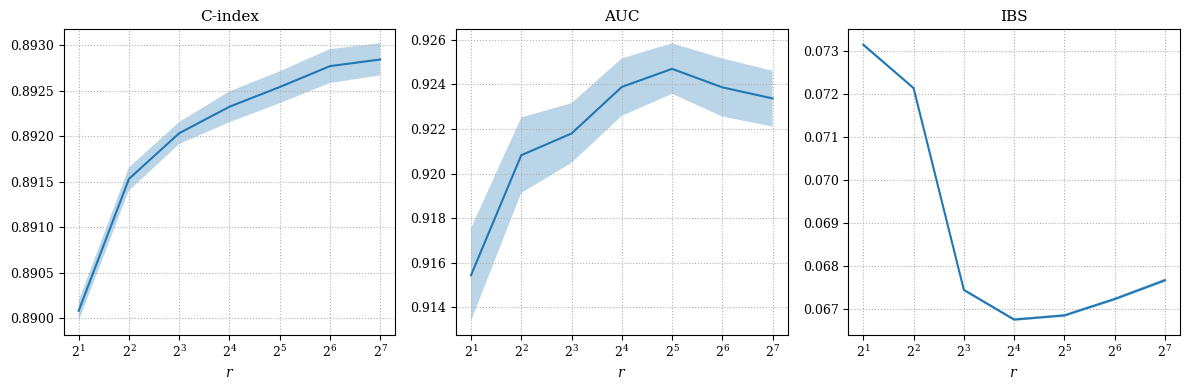

In [35]:
with plt.rc_context(RC_PARAMS):
    fig, axes = plt.subplots(1, 3, sharex=True, figsize=(12, 4))
    for i, k in enumerate(['c_index', 'auc', 'ibs']):
        ax = axes[i]
        mean = np.mean(results_steps[k], axis=0)
        # p_min, p_max = np.percentile(results_steps[k], (5, 95), axis=0)
        # p_min, p_max = mean - np.std(results[k], axis=0), mean + np.std(results[k], axis=0)
        p_min = np.zeros(results_steps[k].shape[1])
        p_max = np.zeros(results_steps[k].shape[1])
        for j in range(results_steps[k].shape[1]):
            cur_arr = results_steps[k][:, j]
            bootstrap_means = [np.mean(np.random.choice(cur_arr, size=results_steps[k].shape[0], replace=True)) for _ in range(10000)]
            p_min_cur, p_max_cur = np.percentile(bootstrap_means, [2.5, 97.5])
            p_min[j] = p_min_cur
            p_max[j] = p_max_cur
        ax.plot(steps_grid, mean)
        ax.fill_between(steps_grid, p_min, p_max, alpha=0.3)
        ax.set_xticks(steps_grid)
        ax.grid(ls=':')
        ax.set_title(get_metric_name(k))
        ax.set_xlabel('$r$')
        ax.set_xscale("log", base=2)
        ax.set_xticks(steps_grid)
        # if k == 'c_index':
        #     ax.set_ylim(0.888, 0.896)
    plt.tight_layout()
    plt.show()

In [36]:
fig.savefig('ablation_n_steps.png', dpi=300)